# A 2-Hour Python Crash Course

Welcome! This single notebook is a fast, guided sprint through the parts of Python
you need to start doing data science in the brain and behavioral sciences. It is
designed to be **worked through in about two hours, by typing and running the code
yourself** -- not just reading it.

It does **not** replace the full chapters (P01-P09); those go deeper and explain
*why* things work. Think of this as a map of the territory you can finish in an
afternoon, after which the full chapters will make much more sense.

## How to use this

Run each code cell (Shift+Enter), read the comment above each block, then change a
number and run it again. The whole point is to build intuition by poking at things.

| Section | Topic | ~Time |
|---|---|---|
| 0 | Jupyter survival kit | 5 min |
| 1 | Values, variables, and types | 15 min |
| 2 | Containers: lists, tuples, dicts, sets | 20 min |
| 3 | Control flow and comprehensions | 20 min |
| 4 | Functions | 15 min |
| 5 | NumPy: arrays and vectorized math | 20 min |
| 6 | pandas: tables of trials | 20 min |
| 7 | matplotlib: plotting | 15 min |
| 8 | Mini-project: analyze a simulated experiment | 10 min |

Throughout, you'll see **Human check** callouts. Those mark places where code can
run perfectly and still be scientifically wrong -- the moments where your judgment
matters most (and where you should be most skeptical of code an AI wrote for you).

## 0. Jupyter survival kit  *(~5 min)*

A notebook is a list of **cells**. A cell is either **text** (Markdown, like this
one) or **code** (Python). To run a code cell, click it and press **Shift+Enter**.
The value of the *last line* of a code cell is displayed automatically; for
anything else, use `print(...)`.

In [1]:
# this is a code cell -- run it with Shift+Enter
2 + 2          # the last line's value is shown automatically

4

In [2]:
# use print() when you want to show more than just the last line
print("hello")
print(3 * 7)

hello
21


## 1. Values, variables, and types  *(~15 min)*

A **variable** is a name for a value. Python figures out the **type** for you.
The four atomic types you will use constantly are integers, floats, strings, and
booleans.

In [3]:
subject_id = 7            # int   (whole number)
contrast = 0.08           # float (decimal number)
condition = "congruent"   # str   (text, in quotes)
correct = True            # bool  (True or False)

# type() tells you what something is
print(type(subject_id), type(contrast), type(condition), type(correct))

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>


In [4]:
# f-strings build text out of variables -- the modern, readable way
reaction_time = 0.412
print(f"subject {subject_id}: {condition} trial, RT = {reaction_time*1000:.0f} ms")

subject 7: congruent trial, RT = 412 ms


In [5]:
# arithmetic works as you'd expect; note the two kinds of division
print(7 / 2)     # 3.5  -> normal (float) division
print(7 // 2)    # 3    -> integer (floor) division
print(7 % 2)     # 1    -> remainder (modulo)
print(2 ** 10)   # 1024 -> exponent

3.5
3
1
1024


:::{admonition} Human check — floats are not exact
:class: warning
`0.1 + 0.2` is `0.30000000000000004`, not `0.3`, so `0.1 + 0.2 == 0.3` is `False`.
Never compare floats with `==`; use `math.isclose(a, b)` or `numpy.isclose`. This
bites people (and AI-written code) constantly.
:::

In [6]:
print(0.1 + 0.2)            # not exactly 0.3
print(0.1 + 0.2 == 0.3)     # False
import math
print(math.isclose(0.1 + 0.2, 0.3))   # True -- the right way to compare

0.30000000000000004
False
True


## 2. Containers: lists, tuples, dicts, sets  *(~20 min)*

Real data comes in collections. The four you must know:

* **list** `[...]` -- an ordered, changeable sequence (a column of RTs).
* **tuple** `(...)` -- an ordered, *unchangeable* sequence (a coordinate, a record).
* **dict** `{key: value}` -- a lookup table (condition -> list of RTs).
* **set** `{...}` -- an unordered collection of *unique* items.

In [7]:
# a LIST of reaction times (ms)
rts = [412, 520, 380, 660, 290, 505]
print(rts[0])      # first element (Python counts from 0!)
print(rts[-1])     # last element
print(rts[:3])     # slice: first three
print(len(rts))    # how many

rts.append(450)    # add to the end
print(rts)

412
505
[412, 520, 380]
6
[412, 520, 380, 660, 290, 505, 450]


In [8]:
# a TUPLE -- like a list but immutable; great for fixed records
trial = (7, "congruent", 0.412)     # (subject, condition, rt)
subject, cond, rt = trial            # unpack into three names at once
print(subject, cond, rt)

7 congruent 0.412


In [9]:
# a DICT maps keys to values
mean_rt_by_condition = {"congruent": 488.0, "incongruent": 640.0}
print(mean_rt_by_condition["incongruent"])     # look up by key

# loop over keys and values together
for condition, mean_rt in mean_rt_by_condition.items():
    print(f"{condition}: {mean_rt} ms")

640.0
congruent: 488.0 ms
incongruent: 640.0 ms


In [10]:
# a SET keeps only unique items
stimuli_shown = {101, 102, 103, 102, 101}
print(stimuli_shown)                  # duplicates dropped
print(102 in stimuli_shown)           # fast membership test

{101, 102, 103}
True


:::{admonition} Human check — 0-based indexing and exclusive slices
:class: warning
Python counts from **0**, and a slice `a[start:stop]` *excludes* `stop`. So
`rts[0]` is the first trial and `rts[0:3]` is trials 0, 1, 2 (three items, not
four). Off-by-one errors here silently drop or shift data without raising anything.
:::

## 3. Control flow and comprehensions  *(~20 min)*

Programs make decisions (`if`) and repeat work (`for`/`while`). **Indentation**
(4 spaces) defines what is inside a block -- Python has no curly braces.

In [11]:
rt = 412
# if / elif / else -- note the colons and the indentation
if rt < 300:
    label = "very fast (maybe a guess?)"
elif rt < 600:
    label = "typical"
else:
    label = "slow"
print(label)

typical


In [12]:
# a for-loop walks through a collection
rts = [412, 520, 380, 660, 290, 505]
total = 0
for value in rts:
    total += value          # shorthand for: total = total + value
print("mean:", total / len(rts))

mean: 461.1666666666667


In [13]:
# enumerate gives you the index, zip walks two lists together
accuracy = [1, 1, 0, 1, 1, 0]
for i, (value, ok) in enumerate(zip(rts, accuracy)):
    print(f"trial {i}: rt={value} correct={bool(ok)}")

trial 0: rt=412 correct=True
trial 1: rt=520 correct=True
trial 2: rt=380 correct=False
trial 3: rt=660 correct=True
trial 4: rt=290 correct=True
trial 5: rt=505 correct=False


In [14]:
# a LIST COMPREHENSION is a loop + filter in one line -- very Pythonic
correct_rts = [r for r, ok in zip(rts, accuracy) if ok]
print(correct_rts)

# the same idea builds a transformed list
rts_in_seconds = [r / 1000 for r in rts]
print(rts_in_seconds)

[412, 520, 660, 290]
[0.412, 0.52, 0.38, 0.66, 0.29, 0.505]


:::{admonition} Human check — guard your while-loops
:class: warning
A `while` loop runs until its condition becomes `False`. If that never happens
(e.g. an adaptive staircase that never converges), it runs forever. Always include
a hard cap -- loop with `for trial in range(max_trials):` or add a counter and
`break`. AI-generated loops often omit this safety net.
:::

## 4. Functions  *(~15 min)*

A **function** packages up code you want to name and reuse. Define it with `def`,
hand it inputs (arguments), and get back a value with `return`.

In [15]:
def mean(values):
    """Return the arithmetic mean of a list of numbers."""
    return sum(values) / len(values)

print(mean([412, 520, 380]))

437.3333333333333


In [16]:
# arguments can have defaults, and you can document types with hints
def z_score(value: float, mu: float, sigma: float) -> float:
    """How many standard deviations is `value` from the mean?"""
    return (value - mu) / sigma

print(round(z_score(640, mu=500, sigma=60), 2))

2.33


:::{admonition} Human check — the mutable default argument trap
:class: warning
Writing `def collect(rt, out=[])` creates the list **once** and reuses it across
every call, so data from one participant leaks into the next. It runs fine in a
quick test and corrupts real analyses. Use `None` as the default and create the
list inside:

```python
def collect(rt, out=None):
    if out is None:
        out = []
    out.append(rt)
    return out
```
:::

## 5. NumPy: arrays and vectorized math  *(~20 min)*

`numpy` gives you the **array**: a grid of numbers you can do math on all at once,
far faster than looping. It is the foundation of essentially every scientific
Python tool.

In [17]:
import numpy as np

# make arrays a few different ways
a = np.array([1, 2, 3, 4])
print(a, a.shape, a.dtype)

print(np.arange(0, 10, 2))        # 0,2,4,6,8  (start, stop, step)
print(np.linspace(0, 1, 5))       # 5 evenly spaced points from 0 to 1
print(np.zeros((2, 3)))           # a 2x3 grid of zeros

[1 2 3 4] (4,) int64
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[0. 0. 0.]
 [0. 0. 0.]]


In [18]:
# math happens element-wise, with no loop -- this is the whole point
rts_ms = np.array([412, 520, 380, 660, 290, 505])
rts_s = rts_ms / 1000             # divide every element at once
print(rts_s)

print("mean:", rts_ms.mean(), " std:", round(rts_ms.std(ddof=1), 1))

[0.412 0.52  0.38  0.66  0.29  0.505]
mean: 461.1666666666667  std: 129.0


In [19]:
# a 2D array: 4 subjects (rows) x 3 conditions (columns)
rng = np.random.default_rng(0)            # modern random-number generator
scores = rng.normal(100, 15, size=(4, 3))
print(scores.round(1))

# axis=0 collapses rows (-> one value per condition)
# axis=1 collapses columns (-> one value per subject)
print("per-condition mean:", scores.mean(axis=0).round(1))
print("per-subject mean:   ", scores.mean(axis=1).round(1))

[[101.9  98.  109.6]
 [101.6  92.  105.4]
 [119.6 114.2  89.4]
 [ 81.   90.7 100.6]]
per-condition mean: [101.   98.7 101.3]
per-subject mean:    [103.2  99.7 107.7  90.8]


In [20]:
# boolean indexing: pull out elements that meet a condition
fast = rts_ms[rts_ms < 450]
print("fast trials:", fast)

fast trials: [412 380 290]


:::{admonition} Human check — which axis?
:class: warning
`scores.mean(axis=0)` and `scores.mean(axis=1)` both run and both return
reasonable-looking arrays -- but they answer different scientific questions
(average over subjects vs. average over conditions). Always check `.shape` and
write a comment saying what each axis means. Picking the wrong axis is one of the
most common silent errors in array code.
:::

## 6. pandas: tables of trials  *(~20 min)*

`pandas` is a spreadsheet for Python. Its `DataFrame` is a table with named
columns -- exactly how experimental data is usually stored (one row per trial).

In [21]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(1)

# build a tidy trial-level table: one row per trial
rows = []
for subj in range(1, 4):
    for _ in range(20):
        cond = rng.choice(["congruent", "incongruent"])
        rt = (500 if cond == "congruent" else 600) + rng.normal(0, 50)
        rows.append((subj, cond, rt))

df = pd.DataFrame(rows, columns=["subject", "condition", "rt"])
df.head()

,subject,condition,rt
0,1,congruent,541.080907
1,1,incongruent,616.521854
2,1,incongruent,645.267793
3,1,incongruent,622.318729
4,1,congruent,529.055905


In [22]:
# quick looks at the data
print(df.shape)            # (rows, columns)
print(df["condition"].value_counts())
df.describe()

(60, 3)
condition
incongruent    31
congruent      29
Name: count, dtype: int64


,subject,rt
count,60.000000,60.000000
mean,2.000000,547.400149
std,0.823387,60.575380
min,1.000000,438.632397
25%,1.000000,501.844857
50%,2.000000,535.775403
75%,3.000000,603.427793
max,3.000000,661.232348


In [23]:
# select rows that meet a condition
slow = df[df["rt"] > 650]
print(len(slow), "slow trials")

# group and summarize -- the workhorse of behavioral analysis
df.groupby("condition")["rt"].mean()

1 slow trials


condition
congruent      500.478856
incongruent    591.294261
Name: rt, dtype: float64

In [24]:
# the statistically careful summary for a within-subject design:
# average within each subject first, THEN across subjects
per_subj = df.groupby(["subject", "condition"])["rt"].mean().reset_index()
per_subj.groupby("condition")["rt"].mean()

condition
congruent      498.713749
incongruent    591.666905
Name: rt, dtype: float64

:::{admonition} Human check — the .mean() you want vs the one you typed
:class: warning
`df.groupby("condition")["rt"].mean()` pools every trial, weighting subjects with
more trials more heavily, and silently skips missing (`NaN`) values. For a
within-subject design you usually want to average within subjects first (the second
cell above). Both run without error; only you know which matches your design.
:::

## 7. matplotlib: plotting  *(~15 min)*

`matplotlib` makes figures. Use the **object-oriented** style:
`fig, ax = plt.subplots()` and then call methods on `ax`.

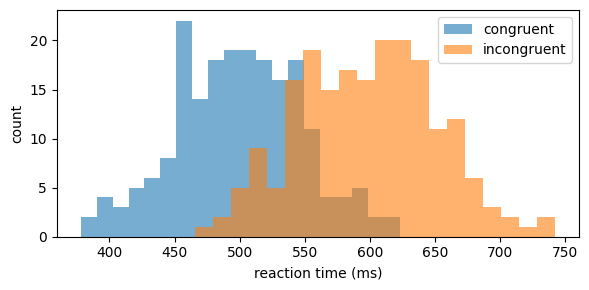

In [25]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(2)
congruent = rng.normal(500, 50, 200)
incongruent = rng.normal(600, 50, 200)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(congruent, bins=20, alpha=0.6, label="congruent")
ax.hist(incongruent, bins=20, alpha=0.6, label="incongruent")
ax.set_xlabel("reaction time (ms)")
ax.set_ylabel("count")
ax.legend()
fig.tight_layout()

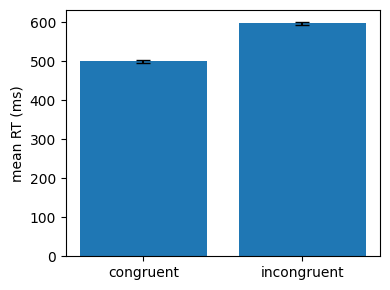

In [26]:
# a bar chart of condition means with standard-error bars
conds = ["congruent", "incongruent"]
data = [congruent, incongruent]
means = [d.mean() for d in data]
sems = [d.std(ddof=1) / np.sqrt(len(d)) for d in data]   # SEM, with sample SD

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(conds, means, yerr=sems, capsize=5)
ax.set_ylabel("mean RT (ms)")
fig.tight_layout()

:::{admonition} Human check — say what your error bars mean
:class: warning
SD, SEM, and 95% confidence intervals look almost identical on a plot but differ by
large factors. Decide which one answers your question, compute it correctly
(`ddof=1` for sample statistics), and label it. A figure with unlabeled error bars
is genuinely ambiguous, no matter how clean the code looks.
:::

## 8. Mini-project: analyze a simulated experiment  *(~10 min)*

Let's tie it together. We will simulate a Stroop-like experiment, then summarize and
plot the congruency effect -- using a list, a dict, NumPy, pandas, and matplotlib in
one short pipeline.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# 1) SIMULATE: 12 subjects, 40 trials each, two conditions
records = []
for subj in range(1, 13):
    subject_effect = rng.normal(0, 30)            # each person is a bit faster/slower
    for _ in range(40):
        cond = rng.choice(["congruent", "incongruent"])
        base = 520 if cond == "congruent" else 600
        rt = base + subject_effect + rng.normal(0, 40)
        records.append((subj, cond, rt))

df = pd.DataFrame(records, columns=["subject", "condition", "rt"])
print(df.shape)
df.head()

(480, 3)


,subject,condition,rt
0,1,incongruent,589.071390
1,1,incongruent,564.413231
2,1,congruent,480.371042
3,1,congruent,522.442649
4,1,congruent,500.348644


In [28]:
# 2) SUMMARIZE within-subject, then across subjects
per_subj = df.groupby(["subject", "condition"])["rt"].mean().reset_index()
summary = per_subj.groupby("condition")["rt"].agg(["mean", "std", "count"])
summary["sem"] = summary["std"] / np.sqrt(summary["count"])
summary

,mean,std,count,sem
condition,,,,
congruent,503.821048,24.575669,12,7.094385
incongruent,583.558686,26.018612,12,7.510926


In [29]:
# 3) the congruency effect, computed per subject (the within-subject difference)
wide = per_subj.pivot(index="subject", columns="condition", values="rt")
effect = wide["incongruent"] - wide["congruent"]
print(f"mean congruency effect: {effect.mean():.1f} ms")
print(f"every subject positive? {(effect > 0).all()}")

mean congruency effect: 79.7 ms
every subject positive? True


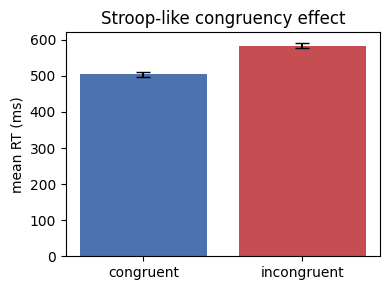

In [30]:
# 4) PLOT: condition means with SEM error bars
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(summary.index, summary["mean"], yerr=summary["sem"], capsize=5,
       color=["#4C72B0", "#C44E52"])
ax.set_ylabel("mean RT (ms)")
ax.set_title("Stroop-like congruency effect")
fig.tight_layout()

## Where to go next

You now have a working vocabulary: types, containers, control flow, functions,
arrays, tables, and plots. To go deeper:

* Work through the full chapters **P01-P09** -- they explain the *why* behind
  everything here and cover important details this sprint skipped.
* Read each chapter's **"Applications & Modern Python"** companion for
  neuroscience/psychology examples and the traps to avoid.
* When you start using an AI assistant to write code, read **Appendix B: Coding
  with AI** first -- especially the section on code that runs but is wrong, which
  is exactly the kind of bug this crash course has been flagging.

Happy coding!